## Lasso modelini Izgara Araması(Grid Search) ile optimizasyonu

In [1]:
#Gerekli kütüphanelerin indirilmesi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score


In [2]:
# Veri setini indirelim.
veri= pd.read_excel("https://www.dropbox.com/s/luoopt5biecb04g/SATILK_EV1.xlsx?dl=1",index_col=0)
veri.head()

,Fiyat,Oda_Sayısı,Net_m2,Katı,Yaşı
0,475,1,40,0,6
1,475,1,55,0,5
2,450,1,50,0,7
3,450,1,55,1,6
4,475,1,45,2,7


In [3]:
# Hedef ve öznitelik değişkenlerini (x) tanımlayalım,Veriyi bölelim:
x=veri [["Oda_Sayısı","Net_m2","Katı","Yaşı"]]
y=veri["Fiyat"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [4]:
#Algoritmayı seçelim ve önemli parametreleri için alternatif değer serileri oluşturalım.
lasso=Lasso(random_state=42)
parametreler={"alpha":[1e-15,1e-10,1e-4,1e-3,1e-2,1,2,3,4,5,10,20,30,50]}

In [6]:
#Grid search değerlendirme için bir yöntem seçmemiz lazım ,ben r2 seçtim MSE,MAE vb kulanıbilir.
#cv ise kaç tane parçaya böleceğini belirler.cv=4 demek farklı farklı 4 defa rasetgeşe eğtim ve test seti ayırmaya ve daha sonra bunların ortlaması alınır.
#4 parça ise sırasıyla birisi test seti olur diğerleri train bu şekilde tarama yapar
#bu sayede rastgelellik ve doğruluk artıyoor.

lasso_gs=GridSearchCV(lasso,parametreler,scoring='r2',cv=5)

#parametreleri tanımladık

In [9]:
#modeli eğitelim.
lasso_gs.fit(x_train,y_train)


c:\Users\enesc\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.888e+05, tolerance: 1.557e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\enesc\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.124e+05, tolerance: 1.481e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\enesc\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.880e+05, toleranc

GridSearchCV(cv=5, estimator=Lasso(random_state=42),
             param_grid={'alpha': [1e-15, 1e-10, 0.0001, 0.001, 0.01, 1, 2, 3,
                                   4, 5, 10, 20, 30, 50]},
             scoring='r2')

In [15]:
#en iyi modeli oluşturacak alpha ve L1_ratio değeri 
print(lasso_gs.best_params_)
print()
# en iyi modeli üretecek tüm lasso hiperparametreleri 
print(lasso_gs.best_estimator_)
print()
# 5 alternatif eğtim setinin r2 lerin ortalaması 
print(lasso_gs.best_score_) # bu en iyisi değil ortlamasıdır.



{'alpha': 1}

Lasso(alpha=1, random_state=42)

0.7070875030803956


In [20]:
#Çapraz doğrulama (cross-validation)
all_accuracies=cross_val_score(estimator=lasso_gs.best_estimator_,X=x_train,y=y_train,cv=5)

In [23]:
#Çapraz doğrulama sonuçları:
print("score",all_accuracies) #  farklı denemedeki score değerleri

print("ortalama r2",all_accuracies.mean())#ortalama başarı
print("standart sapma",all_accuracies.std())#standart sapma yani ne kadar skorların dalgalandığını söyler.


score [0.59123045 0.86153674 0.75880023 0.58955277 0.73431731]
ortalama r2 0.7070875030803956
standart sapma 0.10441025340334989


In [30]:
#tahmin modelinin kaysaıları
#lassonun ürettiği en iyi modelin tahmin parametreleri:
sabit=lasso_gs.best_estimator_.intercept_
print("sabit deger:",sabit)

oznitelik_katsayilari=pd.DataFrame(
                                   lasso_gs.best_estimator_.coef_,x.columns,
                                   columns=['Lasso (a=1)öznitelik kaysayilari']
                                    )        
oznitelik_katsayilari

sabit deger: 290.73831882264074


,Lasso (a=1)öznitelik kaysayilari
Oda_Sayısı,103.407284
Net_m2,1.619248
Katı,7.086422
Yaşı,-4.055176


In [33]:
#en iyi lasso modelinin eğitim ve test seti üzerindeki performanısna bakalım
lasso_train_score=lasso_gs.best_estimator_.score(x_train,y_train)
lasso_test_score=lasso_gs.best_estimator_.score(x_test,y_test)
print("Eğitim seti için R2:",lasso_train_score)
print("Test seti için R2:",lasso_test_score)


Eğitim seti için R2: 0.7324650909211012
Test seti için R2: 0.6862906745619393


In [34]:
#Tahmin modeli ile tüm veri seti için ev fiyatlarını tahmmin edelim:
veri['Fiyat_Tahmini']=lasso_gs.best_estimator_.predict(x)


In [35]:
#Tahmin edilen ve gerçek ev fiyatları ilk 20 sine bakalım:
print(veri[["Fiyat","Fiyat_Tahmini",]].head(20))

    Fiyat  Fiyat_Tahmini
0     475     434.584450
1     475     462.928338
2     450     446.721749
3     450     465.959585
4     475     452.798357
5     475     458.873162
6     475     471.024575
7     475     446.721749
8     450     454.817987
9     475     452.812470
10    475     442.680687
11    525     532.795059
12    550     562.164677
13    575     507.480616
14    550     515.592769
15    575     528.755799
16    500     518.636328
17    550     472.050306
18    525     488.242781
19    500     495.357430


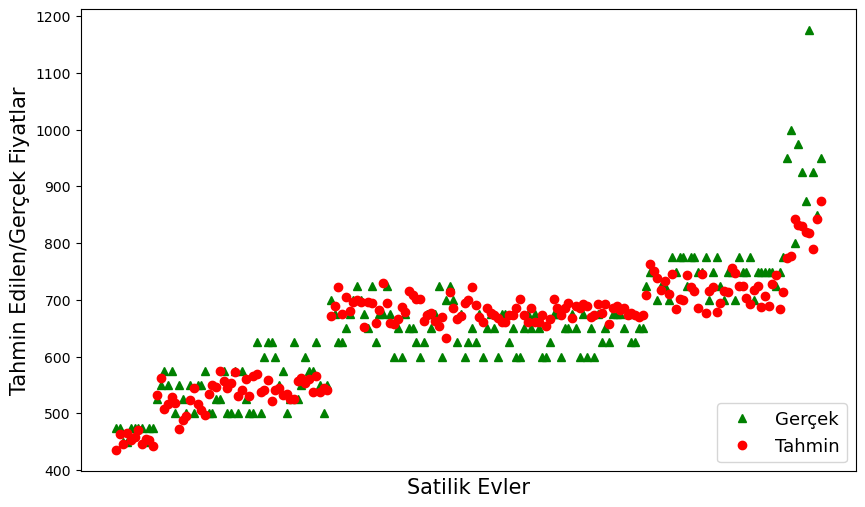

In [40]:
#Grafik: Evlerin gerçek ve tahmin edilmiş fiayatlarını karşılaştırılması:
plt.figure(figsize=(10,6))
plt.xticks(veri["Fiyat"],veri.index.values)
plt.plot(veri["Fiyat"],"g^",label="Gerçek")
plt.xticks(veri["Fiyat_Tahmini"],veri.index.values)
plt.plot(veri["Fiyat_Tahmini"],"ro",label="Tahmin")
plt.xlabel("Satilik Evler",fontsize=15)
plt.ylabel("Tahmin Edilen/Gerçek Fiyatlar",fontsize=15)
plt.legend(fontsize=13,loc="lower right")
plt.show()

In [43]:
#bu model içi 3 odalı,105 m2,4.katta 8 yıllık daire fiyatı tahmini
Oda_Sayısı=3
Net_m2=105
Katı=4
Yaşı=8
print("Yeni Evin Fiyatı :",lasso_gs.best_estimator_.predict([[Oda_Sayısı,Net_m2,Katı,Yaşı]]))


Yeni Evin Fiyatı : [766.88544391]


c:\Users\enesc\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
